1. Input Data

In [13]:
import numpy as np
import torch

data = np.load("frozen_soil_sensor_dataset_test_corrected.npz")

all_T_sensor_clean = data["all_T_sensor"]
params_arr = data["params_arr"]
curve_ids = data["curve_ids"]
t = data["t"]
sensor_z = data["sensor_z"]

# (n_case, Nt, n_sensor) -> (n_case, n_sensor, Nt)
X_sensor_clean = torch.from_numpy(
    all_T_sensor_clean
).permute(0, 2, 1).float()

print("all_T_sensor_clean:", all_T_sensor_clean.shape)
print("X_sensor_clean    :", X_sensor_clean.shape)
print("params_arr        :", params_arr.shape)

all_T_sensor_clean: (220, 61, 11)
X_sensor_clean    : torch.Size([220, 11, 61])
params_arr        : (220, 6)


2. 建立 Inverse DeepONet

2.1. 网络架构

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class BranchCNN(nn.Module):
    """
    Branch net: 传感器温度时序 -> latent 向量 b(u) ∈ R^p
    输入 X_sensor: (B, n_sensors, Nt)
      B          : batch size
      n_sensors  : 传感器个数 (这里是 6)
      Nt         : 时间步数 (这里是 61)
    输出 b: (B, latent_dim)   <-- 这里的 latent_dim 就是 p
    """
    def __init__(self, n_sensors: int, latent_dim: int = 64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(n_sensors, 16, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.ReLU(),
        )
        # 对时间维做全局平均池化 -> (B, 32)
        self.pool = nn.AdaptiveAvgPool1d(1)  # 捕捉温度平均值
        self.ln   = nn.LayerNorm(32)
        self.fc   = nn.Linear(32, latent_dim)

    def forward(self, x):
        # x: (B, n_sensors, Nt)
        h = self.conv(x)              # (B, 32, Nt)
        h = self.pool(h).squeeze(-1)  # (B, 32)
        h = self.ln(h)
        b = self.fc(h)                # (B, latent_dim = p)
        return b


class TrunkNet(nn.Module):
    """
    Trunk net: 温度 T -> t(T) ∈ R^p
    输入 T_query: (n_T,) 或 (B, n_T)
      n_T : 在 T<0 区间上采样的温度点个数
    输出 t: (..., latent_dim)  对每个温度点给出一个 p 维基函数值
    """
    def __init__(self, latent_dim: int = 64, hidden: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, latent_dim)
        )

    def forward(self, T_query):          # T_query 必须是顺序向量
        # 确保是 1D tensor
        if T_query.dim() == 1:
            x = T_query.unsqueeze(-1)    # (n_T, 1)
        else:
            # 如果是 (B, n_T)，也兼容
            x = T_query.unsqueeze(-1)
        t = self.net(x)                  # (..., latent_dim)
        return t


class InverseDeepONetMonotone(nn.Module):
    """
    反演 DeepONet (单调版 + 残余含水量 θ_res):

    输入:
      X_sensor : (B, n_sensors, Nt)   传感器温度时序
      T_query  : (n_T,)               需要输出 SFCC 的温度网格 (升序)

    输出:
      theta    : (B, n_T)
        - 对 T<0 的部分: 在 [theta_res, theta_sat] 内单调非减
        - 对 T>=0 的部分: 直接等于 theta_sat
    """
    def __init__(self,
                 n_sensors: int,
                 latent_dim: int = 64,
                 theta_sat: float = 0.5):
        super().__init__()
        self.branch     = BranchCNN(n_sensors, latent_dim)
        self.trunk      = TrunkNet(latent_dim)
        self.theta_sat  = theta_sat
        self.latent_dim = latent_dim

        # 由 branch 的隐向量预测每个样本的残余含水量系数 (0~1)
        self.fc_res = nn.Linear(latent_dim, 1)

        # 增加一个“陡峭度/尺度”自由度（每个样本 1 个标量）
        self.fc_scale = nn.Linear(latent_dim, 1)

    def forward(self, X_sensor, T_query):
        """
        X_sensor: (B, n_sensors, Nt)
        T_query : (n_T,)  已按从小到大排序, 且包含负温区 + 可能的 0/正温
        """
        device = X_sensor.device
        T_query = T_query.to(device)

        B   = X_sensor.size(0)
        n_T = T_query.numel()

        # -------- 1. 分离 T<0 和 T>=0 --------
        mask_neg = (T_query < 0)          # (n_T,)
        mask_pos = ~mask_neg              # (n_T,)

        idx_neg = torch.nonzero(mask_neg, as_tuple=False).squeeze(-1)  # (n_T_neg,)
        idx_pos = torch.nonzero(mask_pos, as_tuple=False).squeeze(-1)  # (n_T_pos,)

        T_neg = T_query[idx_neg]          # (n_T_neg,)

        # -------- 2. branch: 传感器时序 -> b(u), 再得到 θ_res --------
        # b: (B, latent_dim)
        b = self.branch(X_sensor)         # (B, latent_dim)

        # 每个样本的残余含水量 θ_res ∈ (0, theta_sat)
        # 先映射到 (0,1)，再乘以 theta_sat
        theta_res_frac = torch.sigmoid(self.fc_res(b))   # (B, 1), 0~1
        theta_res = theta_res_frac * self.theta_sat      # (B, 1)

        # -------- 3. trunk: T<0 -> t(T) --------
        t_neg = self.trunk(T_neg)         # (n_T_neg, latent_dim)

        # -------- 4. DeepONet 组合得到一个单调的 0~1 形状函数 s(T) --------
        # raw: (B, n_T_neg)
        theta_raw_neg = torch.matmul(b, t_neg.T)   # (B, n_T_neg)

        # softplus 确保增量非负
        scale = 0.2 + 5.0 * torch.sigmoid(self.fc_scale(b))   # (B,1) > 0
        delta = F.softplus(theta_raw_neg) * scale              # (B,n_T_neg)

        # 沿 T 维累积和 -> 严格单调非减
        theta_cum = torch.cumsum(delta, dim=1)     # (B, n_T_neg)

        eps = 1e-6
        # 归一化到 [0,1]，最后一点 = 1
        s_neg = theta_cum / (theta_cum[:, -1:].clone() + eps)   # (B, n_T_neg), 0~1

        # -------- 5. 映射到 [θ_res, θ_sat] --------
        # 利用广播：theta_res: (B,1)  s_neg: (B,n_T_neg)
        theta_neg = theta_res + (self.theta_sat - theta_res) * s_neg  # (B, n_T_neg)

        # -------- 6. 组装完整 θ(T) --------
        theta = torch.zeros(B, n_T, device=device)

        if idx_neg.numel() > 0:
            theta[:, idx_neg] = theta_neg

        if idx_pos.numel() > 0:
            theta[:, idx_pos] = self.theta_sat

        return theta

4. 加载 DeepONet

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

n_case, n_sensors, Nt = X_sensor_clean.shape
latent_dim = 8
theta_sat = 0.5

deeponet_eval = InverseDeepONetMonotone(
    n_sensors=n_sensors,
    latent_dim=latent_dim,
    theta_sat=theta_sat,
).to(device)

state_dict = torch.load(
    "deeponet_sfcc_operator_train_80.pt",
    map_location=device
)

deeponet_eval.load_state_dict(state_dict)
deeponet_eval.eval()

print("Loaded Train80 SC-DION model.")

Using device: cuda
Loaded Train80 SC-DION model.


5. Noise robustness test

5.1 Reference SFCCs

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

theta_sat = 0.5  # 之前统一的饱和体积含水量

param_cols = ["form_id", "alpha", "beta", "theta_res", "gamma", "n"]
params_df = pd.DataFrame(params_arr, columns=param_cols)
params_df["curve_id"] = curve_ids
print(params_df.head())


   form_id  alpha  beta  theta_res     gamma    n  curve_id
0      2.0    0.0   0.0   0.099743  1.430308  0.0         1
1      2.0    0.0   0.0   0.101682  0.833243  0.0         2
2      2.0    0.0   0.0   0.098324  0.501503  0.0         3
3      2.0    0.0   0.0   0.176258  0.801955  0.0         4
4      2.0    0.0   0.0   0.172534  0.616955  0.0         5


In [17]:
def theta_power_law(T, alpha, beta, theta_sat=0.5):
    T = np.asarray(T, dtype=float)
    x = np.maximum(-T, 1e-6)
    val = alpha * x**beta
    return np.clip(val, 0.0, theta_sat)

# θ = θ_res + (θ_sat - θ_res) * exp(-((T - T0)/γ)^2)
def theta_exponential(T, theta_res, gamma, theta_sat=0.5, T0=0.0):
    T = np.asarray(T, dtype=float)
    val = theta_res + (theta_sat - theta_res) * np.exp(-((T - T0) / gamma)**2)
    return np.clip(val, 0.0, theta_sat)

# VG
def theta_vg(T, theta_res, alpha, n, theta_sat=0.5):
    T = np.asarray(T, dtype=float)
    x = np.maximum(-T, 1e-6)   # 防止 0
    m = 1.0 - 1.0 / n
    val = theta_res + (theta_sat - theta_res) * (1.0 + (alpha * x)**n)**(-m)
    return np.clip(val, 0.0, theta_sat)

# 统一接口：完全按你之前的 theta_w 写法
def theta_w(T, param_row, theta_sat=0.5):
    """
    统一接口：根据 param_row['form_id'] 调用 Form1/2/3.
    param_row: 一行 pandas.Series（params_df.iterrows() 里的 row）
    - form_id = 1: power law      θ = α * (-T)^β
    - form_id = 2: exponential    θ = θ_res + (θ_sat-θ_res)*exp(-((T-T0)/gamma)^2), T0=0
    - form_id = 3: VG simplified  θ = θ_res + (θ_sat-θ_res)*[1+(α*(-T))^n]^(-m), m=1-1/n
    """
    form = int(param_row["form_id"])  # 1, 2, or 3

    if form == 1:
        return theta_power_law(
            T,
            param_row["alpha"],
            param_row["beta"],
            theta_sat=theta_sat,
        )

    elif form == 2:
        return theta_exponential(
            T,
            param_row["theta_res"],
            param_row["gamma"],
            theta_sat=theta_sat,
            T0 = 0.0
        )

    elif form == 3:
        return theta_vg(
            T,
            param_row["theta_res"],
            param_row["alpha"],
            param_row["n"],
            theta_sat=theta_sat
        )
        
    else:
        raise ValueError(f"未知 form_id={form}，期望是 1/2/3")


In [18]:
# 评估用温度网格（和训练范围一致即可）
T_eval_np = np.linspace(-15.0, 0.0, 50).astype("float32")
n_T_eval = T_eval_np.shape[0]
n_case = params_arr.shape[0]

theta_true_np = np.zeros((n_case, n_T_eval), dtype=np.float32)

for i in range(n_case):
    row = params_df.iloc[i]
    theta_true_np[i] = theta_w(T_eval_np, row, theta_sat=theta_sat)

print("theta_true_np shape:", theta_true_np.shape)   # (n_case, 50)


theta_true_np shape: (220, 50)


5.2 SFCC inversion under different noise levels

In [19]:
import numpy as np
import pandas as pd
import torch

# 单位为 °C，表示高斯噪声的标准差
noise_levels = np.array(
    [0.0, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50],
    dtype=np.float32
)

# 每个噪声水平重复20次
n_repeat = 20
random_seed = 42
rng = np.random.default_rng(random_seed)

T_eval = torch.from_numpy(T_eval_np).float().to(device)

rmse_results = np.zeros(
    (len(noise_levels), n_repeat),
    dtype=np.float64
)

r2_results = np.zeros(
    (len(noise_levels), n_repeat),
    dtype=np.float64
)

deeponet_eval.eval()

# 外层为重复实验
for j in range(n_repeat):

    # 每次生成一组标准高斯噪声
    # 同一次重复中，不同噪声水平使用同一组噪声并按sigma缩放
    standard_noise = rng.standard_normal(
        size=all_T_sensor_clean.shape
    ).astype(np.float32)

    for i, sigma in enumerate(noise_levels):

        # 每次都从原始干净测试数据开始加噪
        all_T_sensor_noisy = (
            all_T_sensor_clean
            + float(sigma) * standard_noise
        )

        # (n_case, Nt, n_sensor)
        # -> (n_case, n_sensor, Nt)
        X_sensor_noisy = torch.from_numpy(
            all_T_sensor_noisy
        ).permute(0, 2, 1).float().to(device)

        with torch.no_grad():
            theta_pred = deeponet_eval(
                X_sensor_noisy,
                T_eval
            )

        theta_pred_np = theta_pred.cpu().numpy()

        # 所有测试样本和温度点一起计算
        err_global = theta_pred_np - theta_true_np

        # Global RMSE
        rmse_results[i, j] = np.sqrt(
            np.mean(err_global**2)
        )

        # Global R2
        ss_res_global = np.sum(err_global**2)

        ss_tot_global = np.sum(
            (
                theta_true_np
                - np.mean(theta_true_np)
            )**2
        )

        r2_results[i, j] = (
            1.0 - ss_res_global / ss_tot_global
        )

print("Noise robustness test completed.")

Noise robustness test completed.


In [20]:
noise_summary = pd.DataFrame({
    "Noise standard deviation (°C)": noise_levels,
    "Global RMSE mean": rmse_results.mean(axis=1),
    "Global RMSE std": rmse_results.std(axis=1, ddof=1),
    "Global R2 mean": r2_results.mean(axis=1),
    "Global R2 std": r2_results.std(axis=1, ddof=1),
})

display(noise_summary)

,Noise standard deviation (°C),Global RMSE mean,Global RMSE std,Global R2 mean,Global R2 std
0,0.00,0.032020,0.000000,0.908524,0.000000
1,0.05,0.032496,0.000063,0.905780,0.000364
2,0.10,0.033793,0.000125,0.898107,0.000756
3,0.20,0.038173,0.000273,0.869981,0.001859
4,0.30,0.044356,0.000414,0.824441,0.003266
5,0.40,0.051826,0.000504,0.760330,0.004649
6,0.50,0.060016,0.000563,0.678596,0.006030


5.3 Noise robustness figure

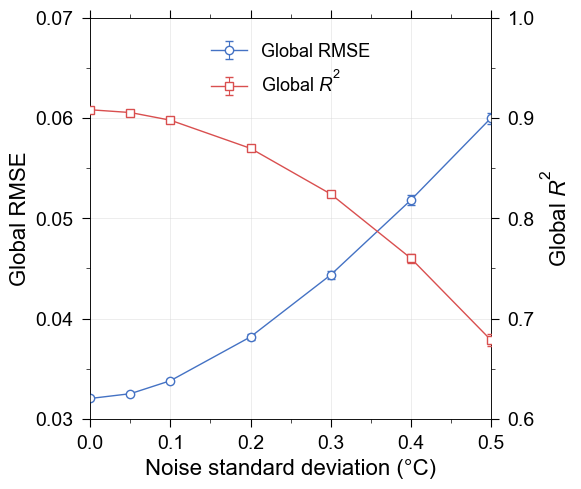

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import MultipleLocator, FormatStrFormatter

# =========================================================
# 1. 可调参数
# =========================================================

FIG_SIZE = 6.0

FONT_FAMILY = "Arial"
FONT_SIZE = 14
LABEL_SIZE = 16
TICK_SIZE = 14
LEGEND_SIZE = 13

LINE_WIDTH = 1.0
MARKER_SIZE = 6.0
MARKER_EDGE_WIDTH = 1.0

ERROR_LINE_WIDTH = 0.8
CAP_SIZE = 3.0

SPINE_WIDTH = 0.5

MAJOR_TICK_LENGTH = 6
MAJOR_TICK_WIDTH = 0.8

MINOR_TICK_LENGTH = 3
MINOR_TICK_WIDTH = 0.5

# 低饱和蓝–红配色
RMSE_COLOR = "#4472C4"
R2_COLOR = "#D94F4F"

# x轴
X_MIN = 0.0
X_MAX = 0.5
X_MAJOR_STEP = 0.1
X_MINOR_STEP = 0.05

# 左侧RMSE轴
RMSE_Y_MIN = 0.03
RMSE_Y_MAX = 0.07
RMSE_MAJOR_STEP = 0.01
RMSE_MINOR_STEP = 0.005

# 右侧R2轴
R2_Y_MIN = 0.6
R2_Y_MAX = 1.0
R2_MAJOR_STEP = 0.1
R2_MINOR_STEP = 0.05


# =========================================================
# 2. 字体
# =========================================================

mpl.rcParams["font.family"] = FONT_FAMILY
mpl.rcParams["font.size"] = FONT_SIZE
mpl.rcParams["axes.labelsize"] = LABEL_SIZE
mpl.rcParams["xtick.labelsize"] = TICK_SIZE
mpl.rcParams["ytick.labelsize"] = TICK_SIZE
mpl.rcParams["legend.fontsize"] = LEGEND_SIZE

mpl.rcParams["mathtext.fontset"] = "custom"
mpl.rcParams["mathtext.rm"] = "Arial"
mpl.rcParams["mathtext.it"] = "Arial:italic"
mpl.rcParams["mathtext.bf"] = "Arial:bold"


# =========================================================
# 3. 统计结果
# =========================================================

rmse_mean = rmse_results.mean(axis=1)
rmse_std = rmse_results.std(axis=1, ddof=1)

r2_mean = r2_results.mean(axis=1)
r2_std = r2_results.std(axis=1, ddof=1)


# =========================================================
# 4. 正方形图幅和双纵坐标
# =========================================================

fig, ax_rmse = plt.subplots(
    figsize=(FIG_SIZE, FIG_SIZE)
)

ax_r2 = ax_rmse.twinx()

# 正方形绘图区
ax_rmse.set_box_aspect(1)

# 网格线位于数据下方
ax_rmse.set_axisbelow(True)


# =========================================================
# 5. RMSE
# =========================================================

rmse_plot = ax_rmse.errorbar(
    noise_levels,
    rmse_mean,
    yerr=rmse_std,
    color=RMSE_COLOR,
    linewidth=LINE_WIDTH,
    marker="o",
    markerfacecolor="white",
    markeredgecolor=RMSE_COLOR,
    markeredgewidth=MARKER_EDGE_WIDTH,
    markersize=MARKER_SIZE,
    elinewidth=ERROR_LINE_WIDTH,
    capsize=CAP_SIZE,
    capthick=ERROR_LINE_WIDTH,
    label="Global SFCC RMSE",
    zorder=3
)


# =========================================================
# 6. R2
# =========================================================

r2_plot = ax_r2.errorbar(
    noise_levels,
    r2_mean,
    yerr=r2_std,
    color=R2_COLOR,
    linewidth=LINE_WIDTH,
    marker="s",
    markerfacecolor="white",
    markeredgecolor=R2_COLOR,
    markeredgewidth=MARKER_EDGE_WIDTH,
    markersize=MARKER_SIZE,
    elinewidth=ERROR_LINE_WIDTH,
    capsize=CAP_SIZE,
    capthick=ERROR_LINE_WIDTH,
    label=r"Global SFCC $R^2$",
    zorder=3
)


# =========================================================
# 7. 坐标轴标题
# 全部使用黑色，避免视觉过于复杂
# =========================================================

ax_rmse.set_xlabel(
    "Noise standard deviation (°C)",
    color="black"
)

ax_rmse.set_ylabel(
    "Global RMSE",
    color="black"
)

ax_r2.set_ylabel(
    r"Global $R^2$",
    color="black"
)


# =========================================================
# 8. 坐标范围
# =========================================================

ax_rmse.set_xlim(X_MIN, X_MAX)
ax_rmse.set_ylim(RMSE_Y_MIN, RMSE_Y_MAX)
ax_r2.set_ylim(R2_Y_MIN, R2_Y_MAX)


# =========================================================
# 9. 主、次刻度位置
# 首尾主刻度与图框重合
# =========================================================

# x轴
ax_rmse.set_xticks(
    np.arange(
        X_MIN,
        X_MAX + X_MAJOR_STEP / 2,
        X_MAJOR_STEP
    )
)

ax_rmse.xaxis.set_minor_locator(
    MultipleLocator(X_MINOR_STEP)
)

# 左侧RMSE轴
ax_rmse.set_yticks(
    np.arange(
        RMSE_Y_MIN,
        RMSE_Y_MAX + RMSE_MAJOR_STEP / 2,
        RMSE_MAJOR_STEP
    )
)

ax_rmse.yaxis.set_minor_locator(
    MultipleLocator(RMSE_MINOR_STEP)
)

# 右侧R2轴
ax_r2.set_yticks(
    np.arange(
        R2_Y_MIN,
        R2_Y_MAX + R2_MAJOR_STEP / 2,
        R2_MAJOR_STEP
    )
)

ax_r2.yaxis.set_minor_locator(
    MultipleLocator(R2_MINOR_STEP)
)


# =========================================================
# 10. 刻度标签格式
# =========================================================

ax_rmse.xaxis.set_major_formatter(
    FormatStrFormatter("%.1f")
)

ax_rmse.yaxis.set_major_formatter(
    FormatStrFormatter("%.2f")
)

ax_r2.yaxis.set_major_formatter(
    FormatStrFormatter("%.1f")
)


# =========================================================
# 11. 刻度样式
# 刻度线朝内，刻度标签保持在图框外
# =========================================================

# x轴：上下均显示刻度线，只在下方显示标签
ax_rmse.tick_params(
    axis="x",
    which="major",
    direction="out",
    length=MAJOR_TICK_LENGTH,
    width=MAJOR_TICK_WIDTH,
    color="black",
    labelcolor="black",
    bottom=True,
    top=True,
    labelbottom=True,
    labeltop=False,
    pad=6
)

ax_rmse.tick_params(
    axis="x",
    which="minor",
    direction="out",
    length=MINOR_TICK_LENGTH,
    width=MINOR_TICK_WIDTH,
    color="black",
    bottom=True,
    top=True
)

# 左侧纵坐标
ax_rmse.tick_params(
    axis="y",
    which="major",
    direction="out",
    length=MAJOR_TICK_LENGTH,
    width=MAJOR_TICK_WIDTH,
    color="black",
    labelcolor="black",
    left=True,
    right=False,
    labelleft=True,
    labelright=False,
    pad=6
)

ax_rmse.tick_params(
    axis="y",
    which="minor",
    direction="out",
    length=MINOR_TICK_LENGTH,
    width=MINOR_TICK_WIDTH,
    color="black",
    left=True,
    right=False
)

# 右侧纵坐标
ax_r2.tick_params(
    axis="y",
    which="major",
    direction="out",
    length=MAJOR_TICK_LENGTH,
    width=MAJOR_TICK_WIDTH,
    color="black",
    labelcolor="black",
    left=False,
    right=True,
    labelleft=False,
    labelright=True,
    pad=6
)

ax_r2.tick_params(
    axis="y",
    which="minor",
    direction="out",
    length=MINOR_TICK_LENGTH,
    width=MINOR_TICK_WIDTH,
    color="black",
    left=False,
    right=True
)


# =========================================================
# 12. 图框
# =========================================================

for spine in ax_rmse.spines.values():
    spine.set_color("black")
    spine.set_linewidth(SPINE_WIDTH)

for spine in ax_r2.spines.values():
    spine.set_color("black")
    spine.set_linewidth(SPINE_WIDTH)


# =========================================================
# 13. 浅色主网格
# =========================================================

ax_rmse.grid(
    which="major",
    axis="both",
    color="#D9D9D9",
    linewidth=0.5,
    alpha=0.65
)

# 不显示次网格
ax_rmse.grid(
    which="minor",
    visible=False
)

ax_r2.grid(False)


# =========================================================
# 14. 图例
# =========================================================

ax_rmse.legend(
    handles=[rmse_plot, r2_plot],
    labels=[
        "Global RMSE",
        r"Global $R^2$"
    ],
    loc="upper center",
    bbox_to_anchor=(0.5, 0.98),
    frameon=False,
    handlelength=2.0
)


# =========================================================
# 15. 显示
# =========================================================

plt.tight_layout()
plt.show()

5.4 Example of noisy temperature observations

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import MultipleLocator

# 选择测试样本和传感器
case_id = 0
sensor_id = 5

# 选择展示的噪声水平
sigma_plot = 0.50  # °C

# 使用与噪声实验相同的随机种子
rng_plot = np.random.default_rng(42)

standard_noise_plot = rng_plot.standard_normal(
    size=all_T_sensor_clean.shape
).astype(np.float32)

all_T_sensor_noisy_plot = (
    all_T_sensor_clean
    + sigma_plot * standard_noise_plot
)

# 提取一个样本中一个传感器的温度时序
temperature_clean = all_T_sensor_clean[
    case_id, :, sensor_id
]

temperature_noisy = all_T_sensor_noisy_plot[
    case_id, :, sensor_id
]

time_plot = np.asarray(t).ravel()

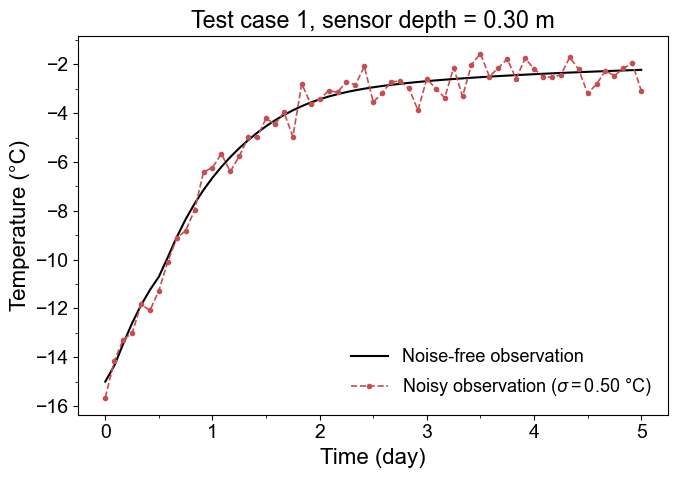

In [23]:
mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["font.size"] = 14
mpl.rcParams["axes.labelsize"] = 16
mpl.rcParams["xtick.labelsize"] = 14
mpl.rcParams["ytick.labelsize"] = 14
mpl.rcParams["legend.fontsize"] = 13

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(
    time_plot,
    temperature_clean,
    color="black",
    linewidth=1.5,
    label="Noise-free observation"
)

ax.plot(
    time_plot,
    temperature_noisy,
    color="#C44E52",
    linewidth=1.2,
    linestyle="--",
    marker="o",
    markersize=3,
    label=fr"Noisy observation ($\sigma={sigma_plot:.2f}$ °C)"
)

ax.set_xlabel("Time (day)")
ax.set_ylabel("Temperature (°C)")

ax.set_title(
    f"Test case {case_id + 1}, "
    f"sensor depth = {sensor_z[sensor_id]:.2f} m"
)

ax.xaxis.set_minor_locator(MultipleLocator(0.5))
ax.yaxis.set_minor_locator(MultipleLocator(1.0))

ax.grid(False)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()